# Pareto PINN–XGBoost de todas las campañas OPT — R5

**Propósito:** comparar todos los modelos individuales completos de las campañas
interpolativas PINN y XGBoost para CO y NOx. No se incluyen ensambles.

**Precisión:** R² mediano de los cinco folds temporales internos sobre DEV.  
**Almacenamiento:** paquete desplegable serializado en MiB.  
**Latencia:** end-to-end p95 CPU1, batch=1, medida sobre cada modelo individual con
100 calentamientos, 1000 inferencias y cinco procesos frescos.

Los ensayos FAIL o PRUNED no aparecen porque no produjeron un modelo completo con las
tres magnitudes necesarias. TEST permanece fuera de esta comparación OPT.

## SEC-01 — Entradas y controles

La tabla consolidada fue construida a partir de PINN CO R5, PINN NOx R6 y XGBoost R2
budget-matched. Los boosters XGBoost representativos fueron reconstruidos sobre DEV y
reprodujeron los nodos y bytes UBJ de la campaña antes de medir su latencia CPU1.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path(r"C:\ChatGPT-Work\Walk_Forward R8")
WORK = PROJECT_ROOT / "models/interp/work_pinn_xgboost_opt_campaign_pareto_latency_r5"
TABLE = WORK / "tables/todos_modelos_individuales_opt_pareto.csv"
FIGURES = WORK / "figures"

models = pd.read_csv(TABLE)
if models.empty:
    raise RuntimeError("La base consolidada está vacía")
if models["ensemble"].astype(str).str.lower().ne("false").any():
    raise RuntimeError("Se detectó un ensamble")
if models["complete_model"].astype(str).str.lower().ne("true").any():
    raise RuntimeError("Se detectó un modelo incompleto")

counts = models.groupby(["target", "family"]).size().rename("modelos_individuales")
display(counts.to_frame())
print({"CHK-01": "PASS", "filas": len(models), "ensambles": 0})

modelos_individuales
target family                       
CO     PINN                       94
       XGBoost                   165
NOx    PINN                       87
       XGBoost                   165

{'CHK-01': 'PASS', 'filas': 511, 'ensambles': 0}


## SEC-02 — Resumen numérico

In [2]:
summary = (
    models.groupby(["target", "family"], as_index=False)
    .agg(
        modelos=("model_id", "count"),
        r2_cv_min=("r2_cv_median", "min"),
        r2_cv_mediana=("r2_cv_median", "median"),
        r2_cv_max=("r2_cv_median", "max"),
        tamano_mib_min=("storage_mib", "min"),
        tamano_mib_max=("storage_mib", "max"),
        latencia_p95_ms_min=("latency_p95_cpu1_ms", "min"),
        latencia_p95_ms_max=("latency_p95_cpu1_ms", "max"),
        no_dominados_3d=("pareto_3d", "sum"),
    )
)
display(summary)

,target,family,modelos,r2_cv_min,r2_cv_mediana,r2_cv_max,tamano_mib_min,tamano_mib_max,latencia_p95_ms_min,latencia_p95_ms_max,no_dominados_3d
0,CO,PINN,94,-0.034209,0.745242,0.760706,0.035466,0.553341,0.04610,0.186260,3
1,CO,XGBoost,165,0.419359,0.677059,0.735713,0.113919,1.541774,0.11030,0.483995,0
2,NOx,PINN,87,-0.046205,0.817345,0.834463,0.026067,0.651366,0.04681,0.180610,18
3,NOx,XGBoost,165,0.069072,0.514062,0.779537,0.038202,0.408811,0.10002,0.396615,0


## SEC-03 — CO: vista 3D y proyecciones 2D lineales

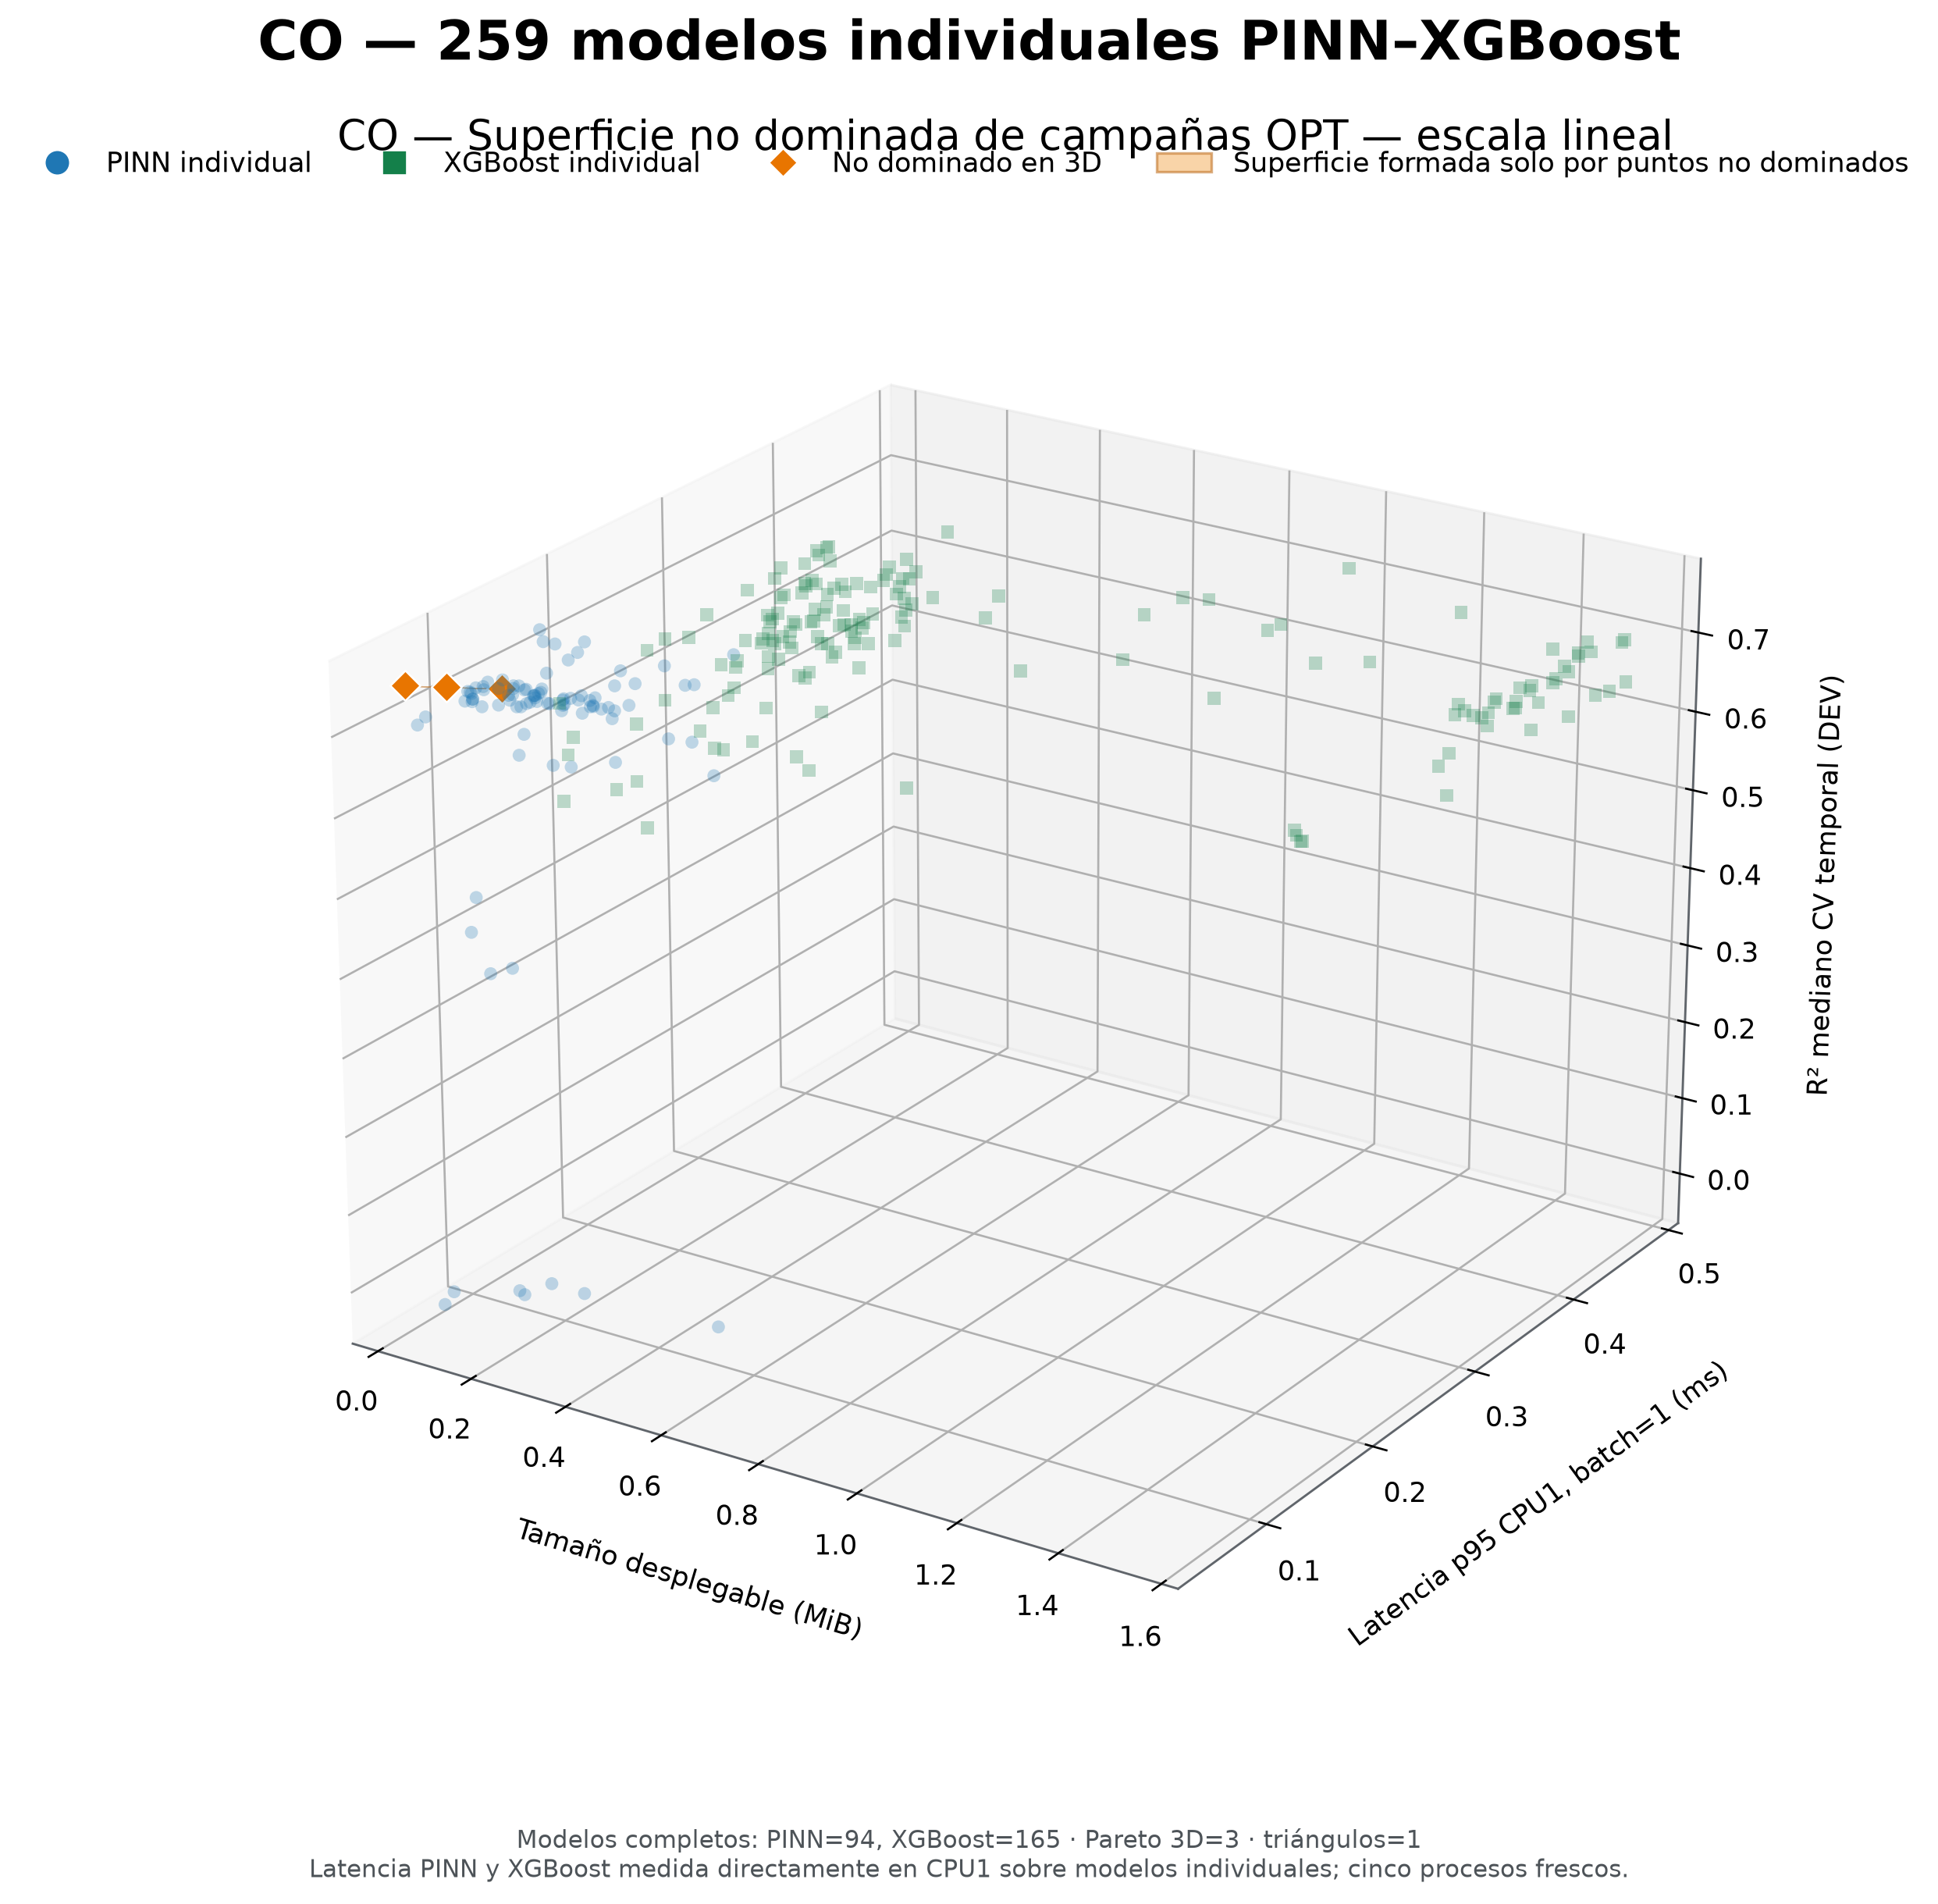

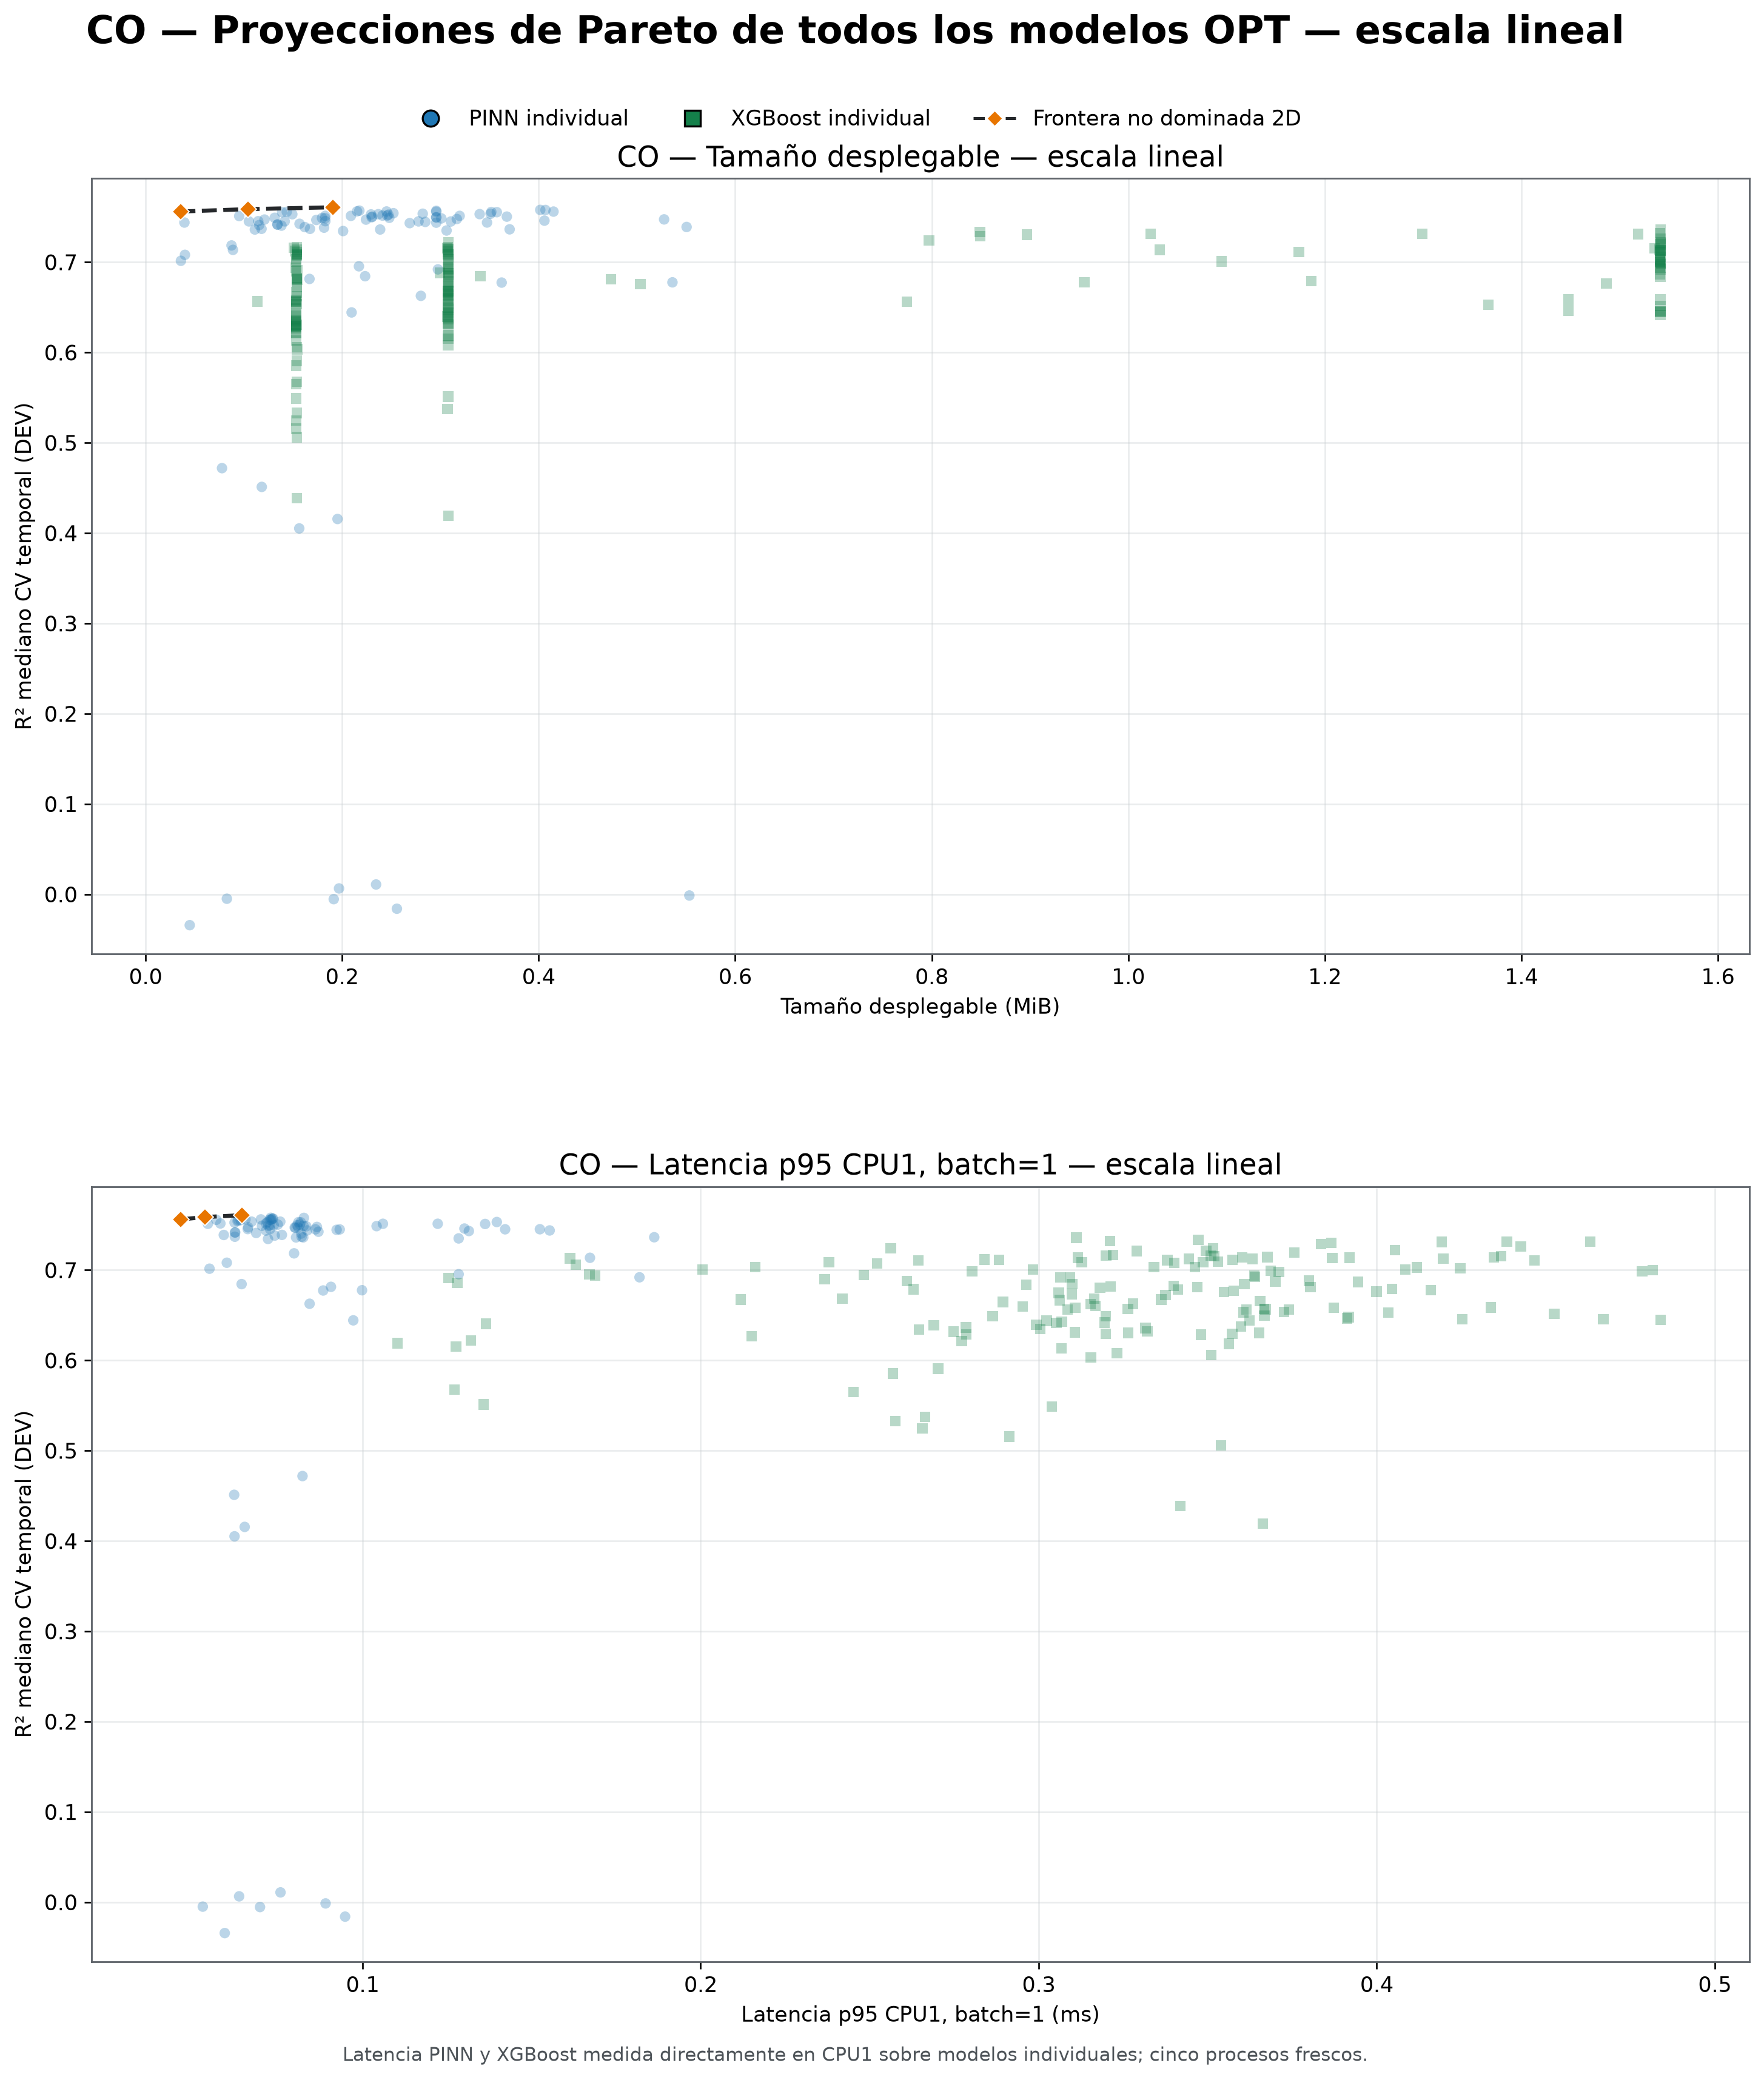

In [3]:
display(Image(filename=str(FIGURES / "01_co_opt_todos_modelos_pareto_3d_lineal.png")))
display(Image(filename=str(FIGURES / "02_co_opt_todos_modelos_pareto_2d_lineal.png")))

## SEC-04 — NOx: vista 3D y proyecciones 2D lineales

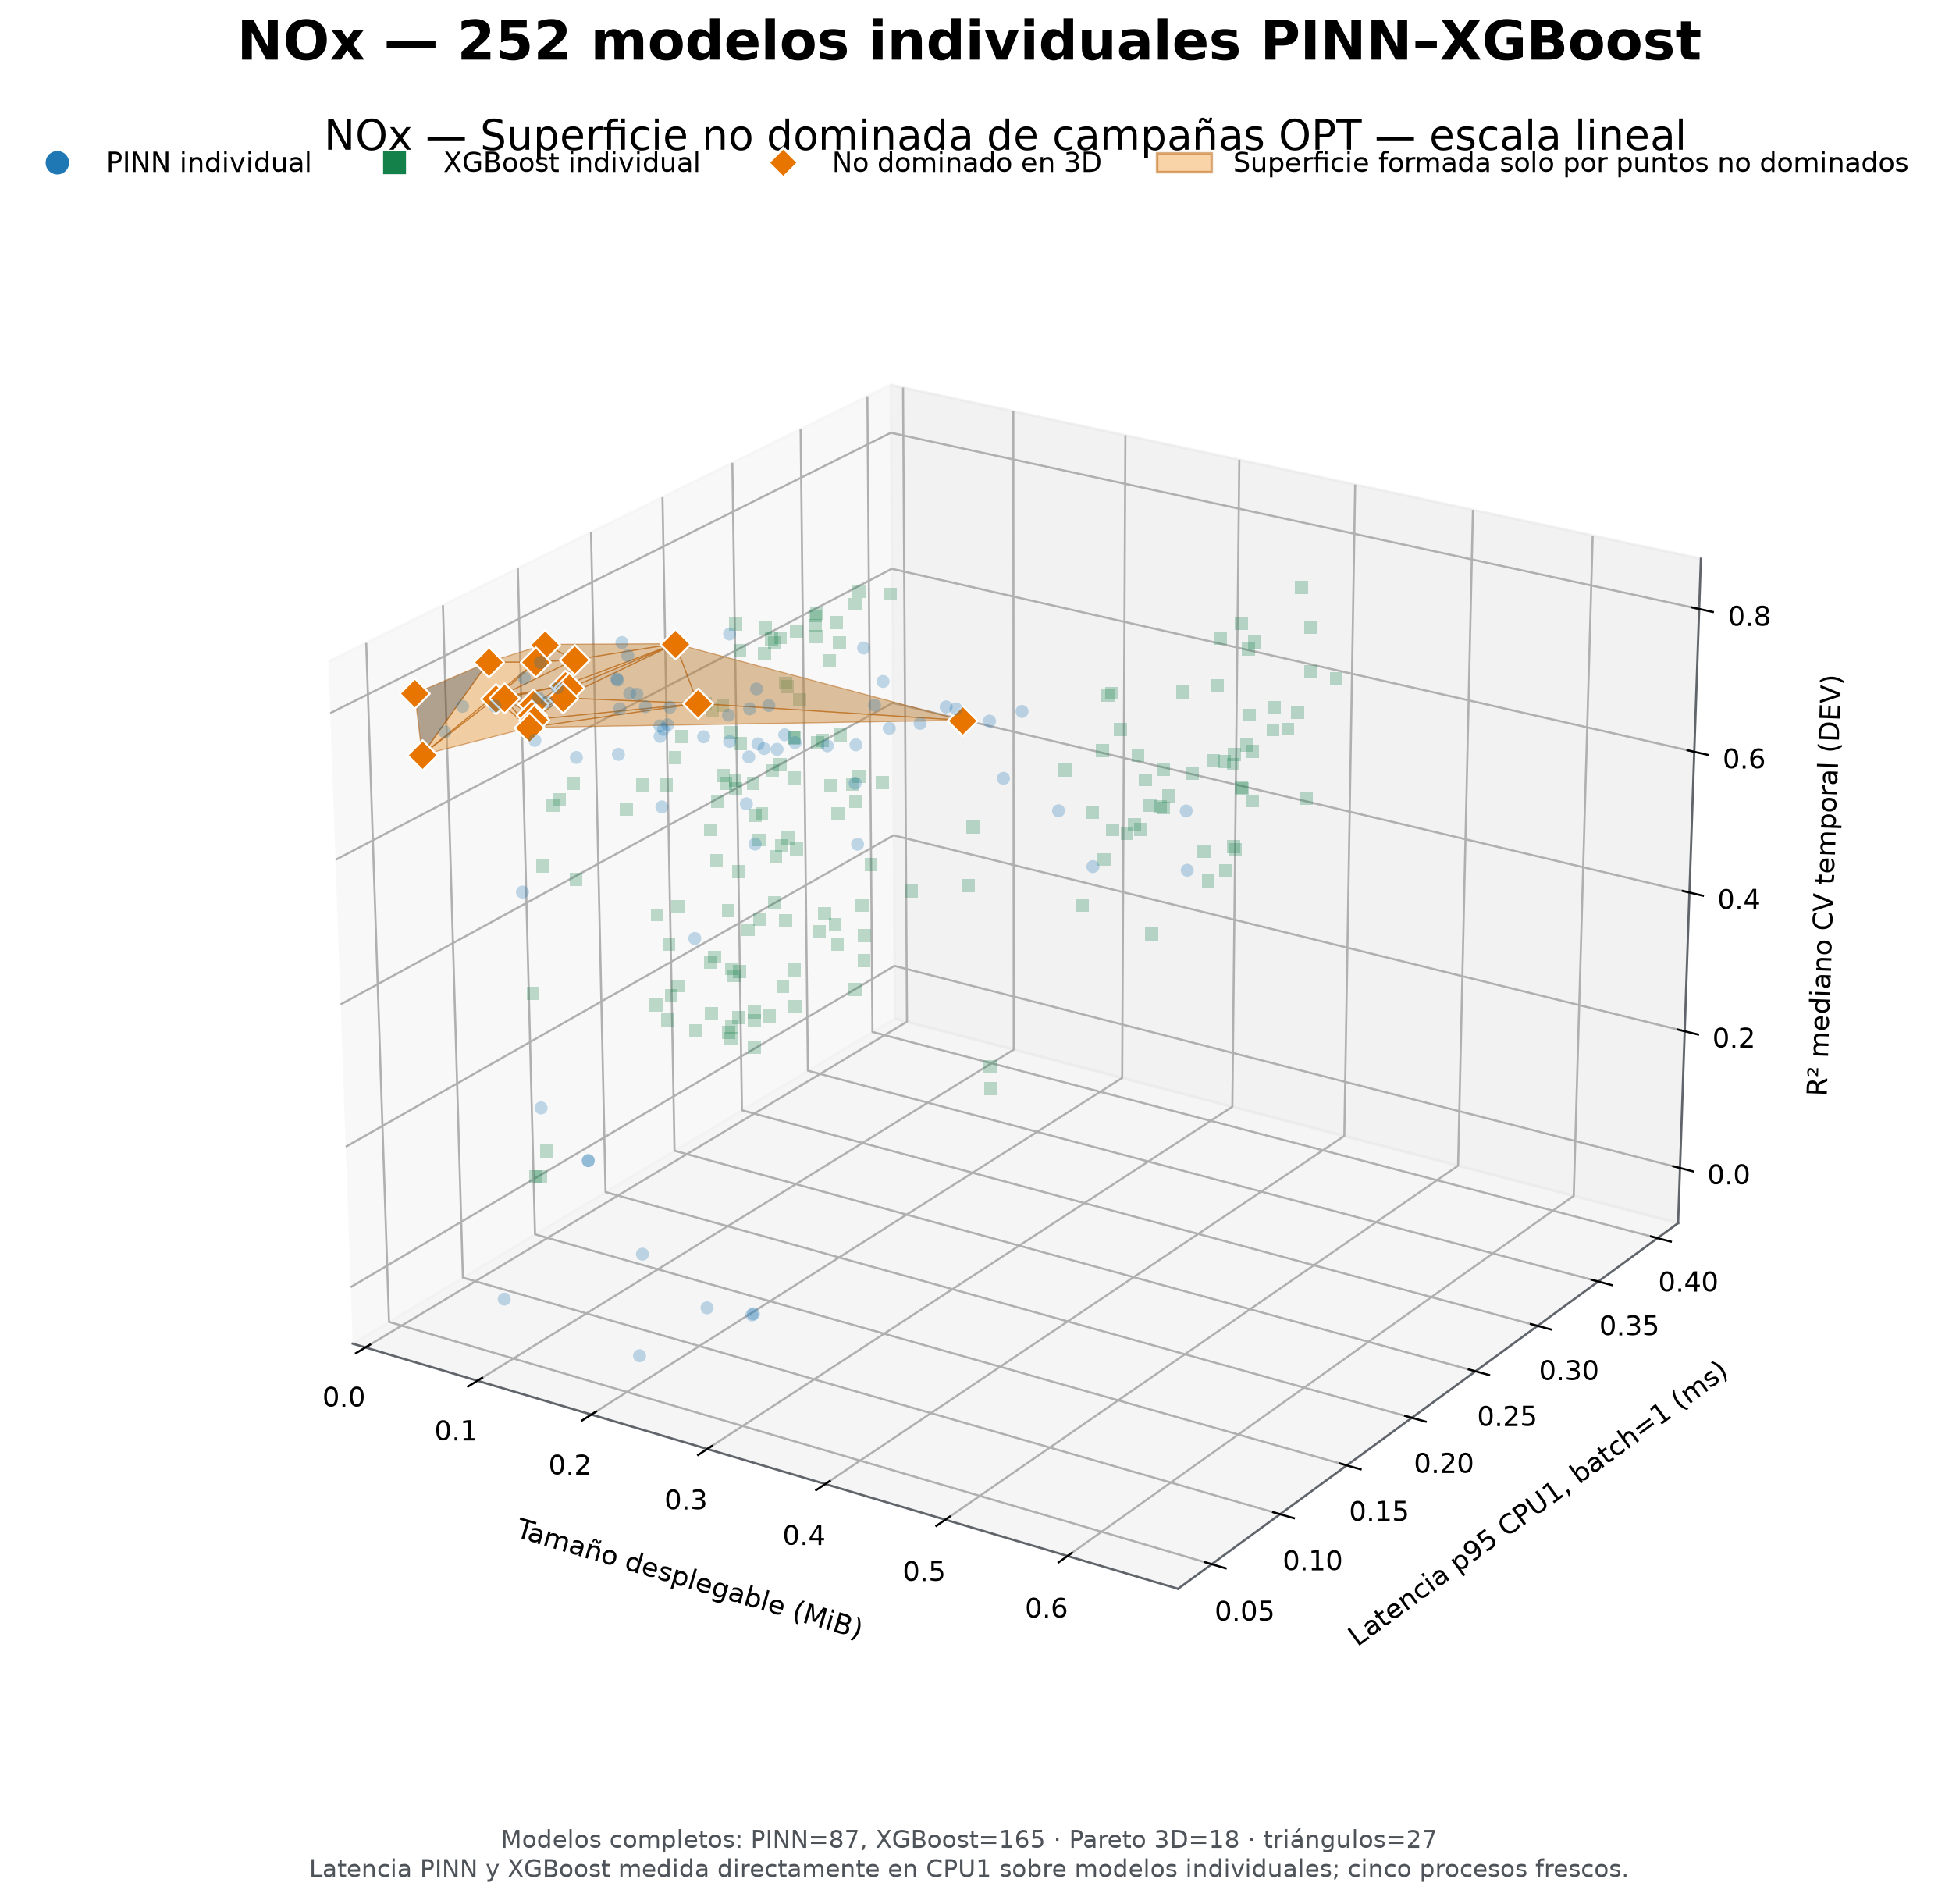

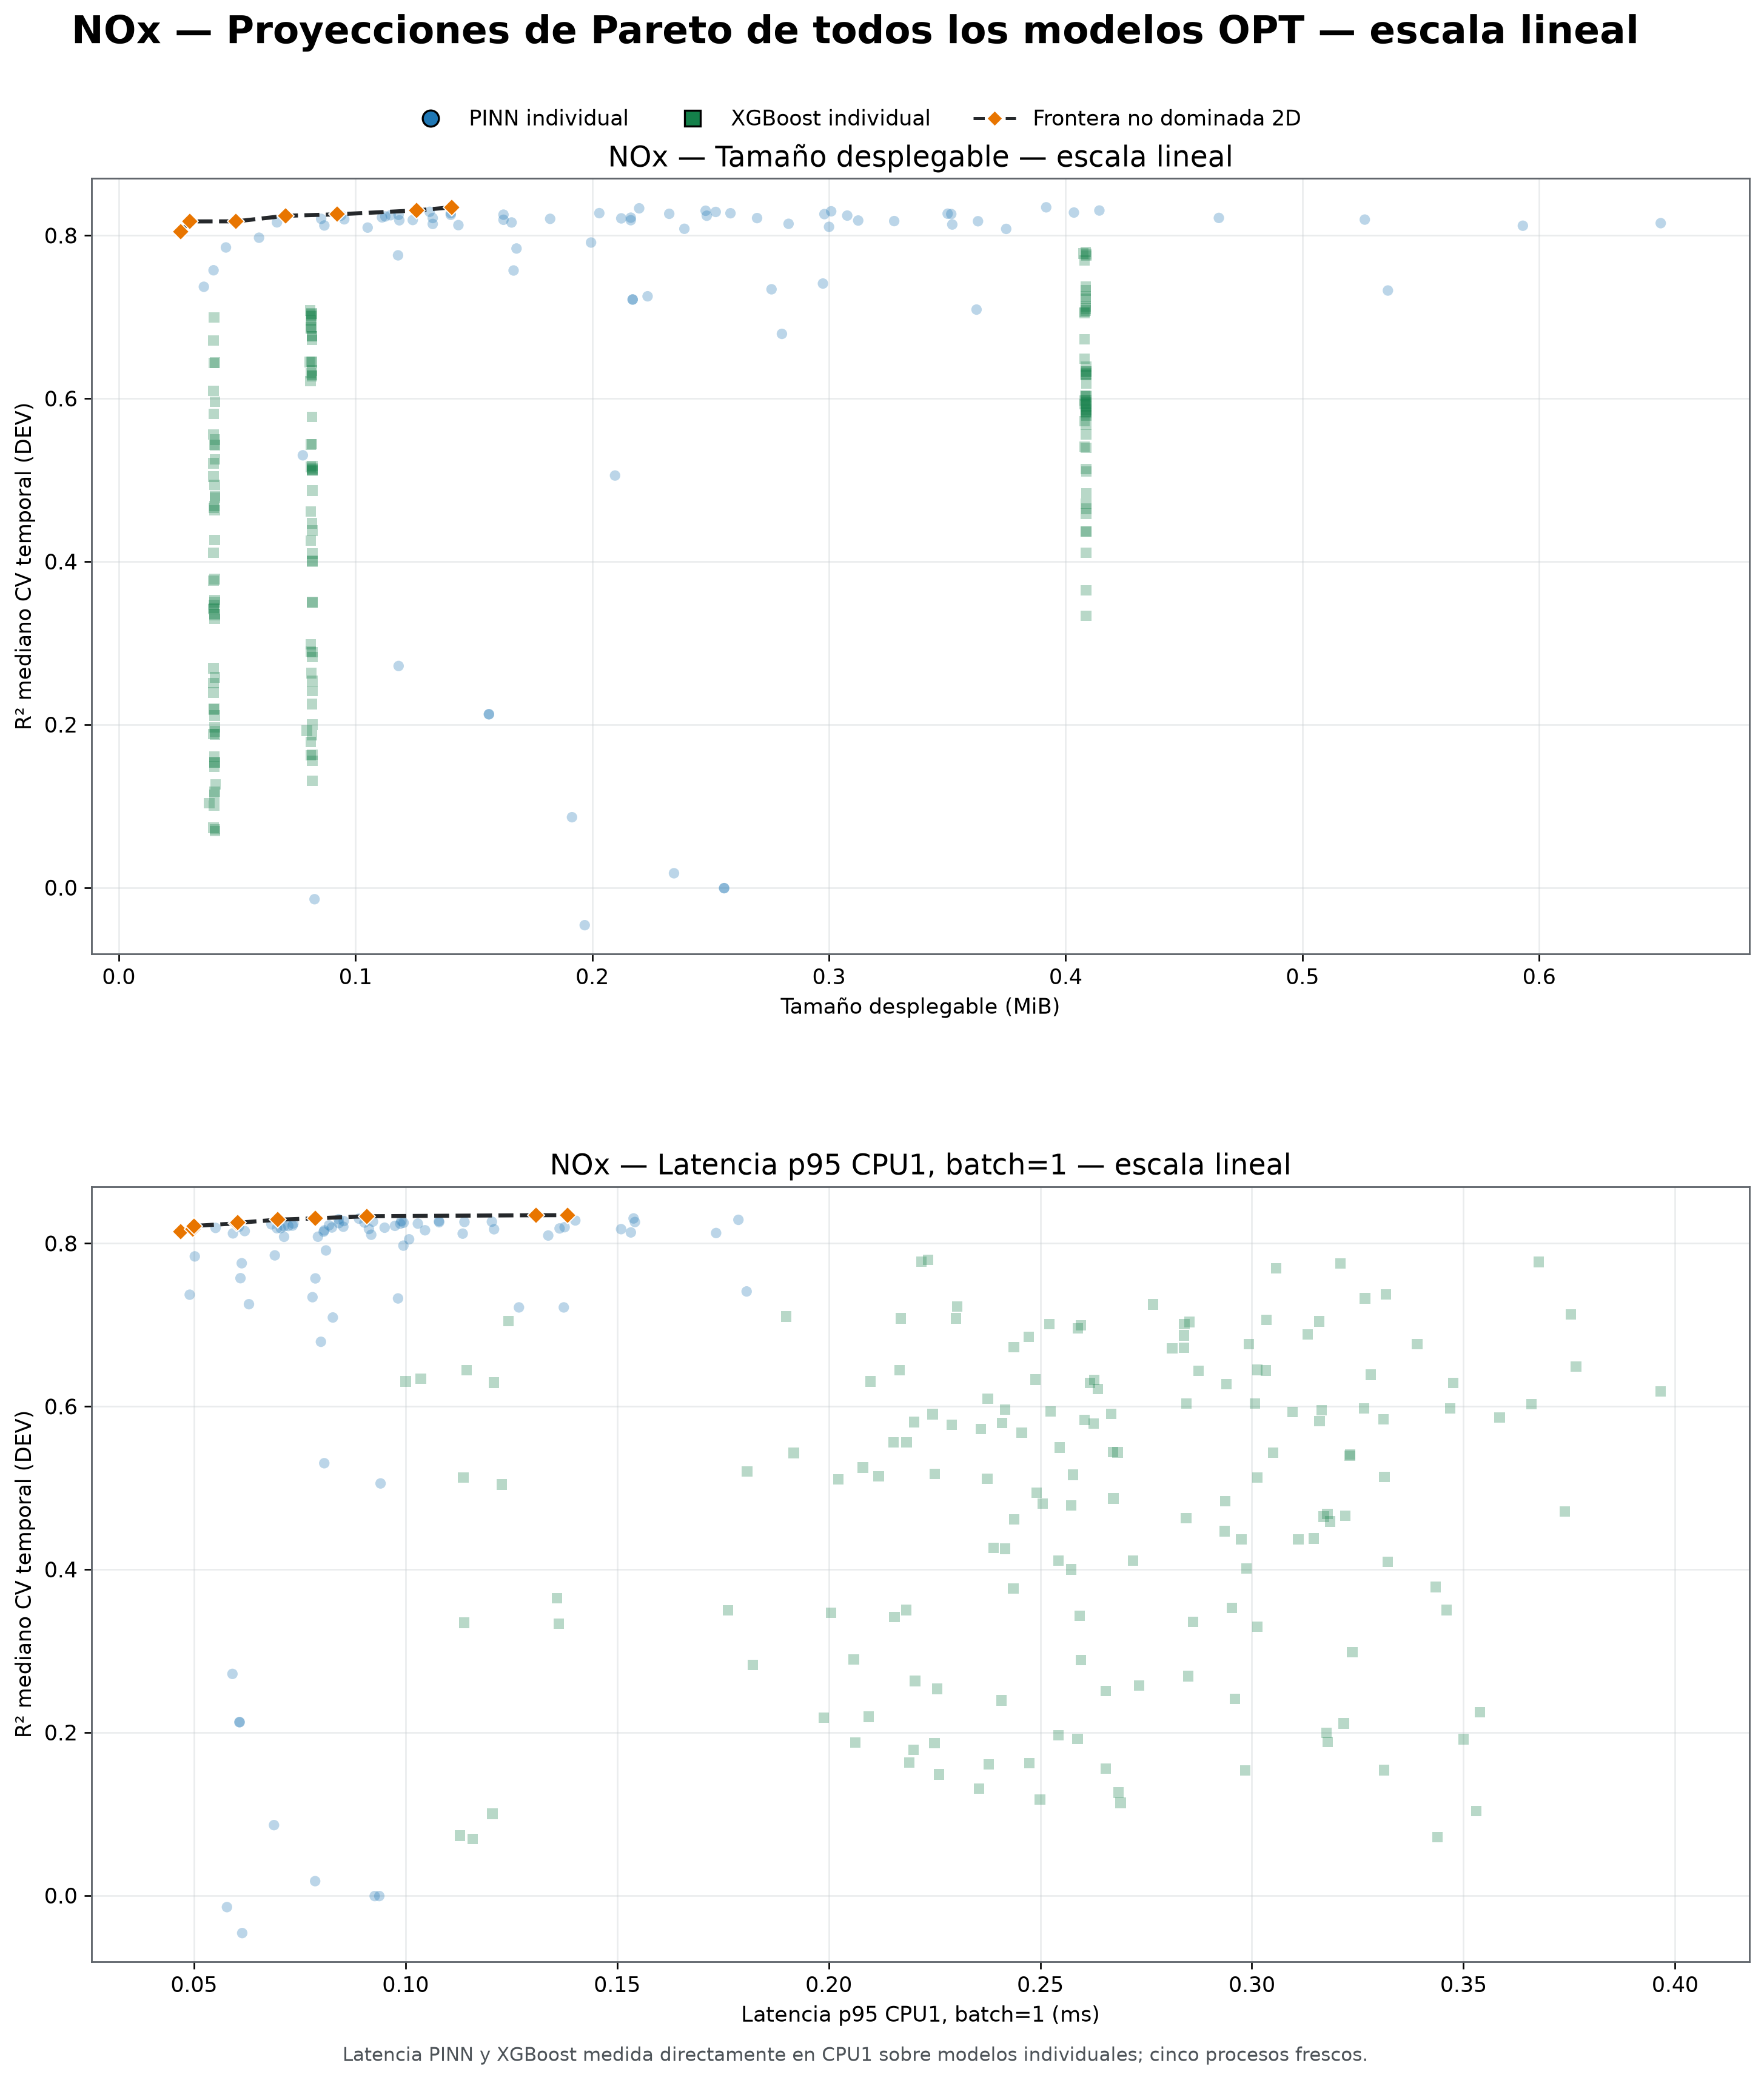

In [4]:
display(Image(filename=str(FIGURES / "01_nox_opt_todos_modelos_pareto_3d_lineal.png")))
display(Image(filename=str(FIGURES / "02_nox_opt_todos_modelos_pareto_2d_lineal.png")))

## SEC-05 — Criterio de interpretación

- Cada punto es un modelo individual completo de OPT.
- La superficie 3D se triangula exclusivamente con los puntos naranjas no dominados.
- Los puntos dominados no intervienen en la geometría de la superficie.
- R² corresponde a CV temporal sobre DEV; no debe interpretarse como rendimiento TEST.
- Las métricas de latencia y almacenamiento describen despliegue individual, no el
  costo de un ensamble.